## 上一节课我们已经学习了调用外部工具，这一节课我们来调用langchain的内置工具

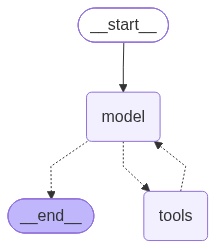

In [12]:
import os

from langchain.agents import create_agent
from dotenv import load_dotenv
from langchain_tavily import TavilyResearch

load_dotenv(override=True)

tavily_api_key = os.getenv("Tavily_api_key")
# 创建langchain内置工具实例
tavily = TavilyResearch(
    max_results=2,
    tavily_api_key=tavily_api_key,
)

agent = create_agent(
    "ollama:carstenuhlig/omnicoder-9b:latest",  # 必须给出模型提供商比,如这里的ollama，这个模型还好
    tools=[tavily]
)
# print(type(agent))
resp = agent.invoke({
    "messages":[
        {"role":"user","content":"请帮我查一下2024年诺贝尔物理学奖得主是谁？"}
    ]
})



from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [13]:
print(resp)

{'messages': [HumanMessage(content='请帮我查一下2024年诺贝尔物理学奖得主是谁？', additional_kwargs={}, response_metadata={}, id='593cf6b4-23e6-404d-81f3-f8b378770afb'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'carstenuhlig/omnicoder-9b:latest', 'created_at': '2026-09-30T00:31:03.8615473Z', 'done': True, 'done_reason': 'stop', 'total_duration': 110891183200, 'load_duration': 26379118000, 'prompt_eval_count': 717, 'prompt_eval_duration': 62100959000, 'eval_count': 97, 'eval_duration': 22099586000, 'logprobs': None, 'model_name': 'carstenuhlig/omnicoder-9b:latest', 'model_provider': 'ollama'}, id='lc_run--01a0efb7-2788-7aa3-bb8f-2559e52031df-0', tool_calls=[{'name': 'tavily_research', 'args': {'input': '2024年诺贝尔物理学奖得主是谁', 'model': 'mini', 'stream': False}, 'id': '52e80603-5588-491f-b876-1f4b51fd5d82', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 717, 'output_tokens': 97, 'total_tokens': 814}), ToolMessage(content='{"status": "pending", "input"

## 使用多个工具


In [14]:
from langchain_core.tools import tool
import os

from langchain.agents import create_agent
from dotenv import load_dotenv
from langchain_tavily import TavilyResearch


load_dotenv(override=True)


@tool(parse_docstring=True)
def get_weather(city:str="广州"):
    """
    查询具体城市的天气

    Args:
          city : 城市名称，如北京

    Returns:
            城市当天的天气
    """
    return f"{city}今天天气很好，阳光明媚，适合郊游~~"


@tool(parse_docstring=True)
def get_news() ->str:
    """
    获取新闻

    Returns:
             返回当前的热点新闻
    """
    return "最近AI智能体非常火爆，有大量的工作岗位缺口，需求量非常大!!!"

agent = create_agent(
    # "ollama:mistral-nemo:latest",  # 必须给出模型提供商比,如这里的ollama:
    # "ollama:granite3.2:8b",  # 必须给出模型提供商比,如这里的ollama:
    "ollama:qwen3-vl:latest",  # 必须给出模型提供商比,如这里的ollama:
    tools=[get_weather,get_news]
)
# print(type(agent))
resp = agent.invoke({
    "messages":[
        {"role":"user","content":"广州今天天气怎么样？最近有什么新闻？"}
    ]
})

print(resp["messages"][-1])


content='广州今天天气晴朗，阳光很好，特别适合去郊游哦！最近的新闻是，AI智能体非常热门，市场上相关岗位需求量大，很多小伙伴都在关注这个领域的发展呢～' additional_kwargs={} response_metadata={'model': 'qwen3-vl:latest', 'created_at': '2026-09-30T00:39:04.7941517Z', 'done': True, 'done_reason': 'stop', 'total_duration': 60058300400, 'load_duration': 37856200, 'prompt_eval_count': 278, 'prompt_eval_duration': 4881950000, 'eval_count': 288, 'eval_duration': 55088088000, 'logprobs': None, 'model_name': 'qwen3-vl:latest', 'model_provider': 'ollama'} id='lc_run--01a0efbf-4487-78d0-a4d1-b40e6e23bca5-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 278, 'output_tokens': 288, 'total_tokens': 566}


## 调用新闻api

In [20]:
from langchain.agents import create_agent
from dotenv import load_dotenv
from tool_utils import query_news_from_web


load_dotenv(override=True)
agent = create_agent(
    # "ollama:mistral-nemo:latest",  # 必须给出模型提供商比,如这里的ollama:
    # "ollama:mistral-nemo:latest",  # 必须给出模型提供商比,如这里的ollama:
    # "ollama:granite3.2:8b",  # 必须给出模型提供商比,如这里的ollama:
    "ollama:mo-shakib/gemma4-e4b-uncensored:q4_k_m",  # 必须给出模型提供商比,如这里的ollama: gemma ok
    tools=[query_news_from_web]
)
# print(type(agent))
resp = agent.invoke({
    "messages":[
        {"role":"user","content":"比亚迪最近有什么新闻？"}
    ]
})

print(resp)


{'messages': [HumanMessage(content='比亚迪最近有什么新闻？', additional_kwargs={}, response_metadata={}, id='71b8c1af-4a89-44ea-ba51-0a76a5207975'), AIMessage(content='您好，关于比亚迪的最新新闻，由于科技和汽车行业的动态变化非常快，不同的侧重点会有不同的报道角度。为了给您一个全面的了解，我为您总结了几个目前主要的关注点和动态（请注意，具体细节需以公司官方最新发布为准）：\n\n**1. 市场和销量表现（核心业务）：**\n*   **销量增长与市场地位：** 比亚迪持续深耕新能源汽车市场，在全球市场，尤其是在电动车和混动车领域表现强劲，持续占据领先地位。近期的报道通常会重点分析其国内外的市场占有率和销量里程碑。\n*   **产品升级：** 公司持续推出高性价比的车型和高端旗舰系列，例如高端化的王朝系列或海洋系列，这些新品发布往往是焦点。\n\n**2. 核心技术与产品创新：**\n*   **刀片电池技术：** 这是比亚迪的标志性技术之一。近期新闻会持续更新电池技术的迭代升级，包括能量密度提升、安全性改进和实际应用场景的拓展。\n*   **全产业链布局：** 比亚迪的优势在于“从电池到车身”的垂直整合能力。因此，关于半导体、新能源电驱系统等非车身部件的进展也会是热点。\n*   **智能化升级：** 智能化是汽车行业的重点。新闻报道会关注其最新的智能驾驶辅助系统（ADAS）、人机交互界面（HMI）的升级，以及在软件定义汽车（SDV）方面的进展。\n\n**3. 国际化布局（海外市场）：**\n*   **品牌国际化：** 比亚迪正在积极将品牌推向全球，目前的消息重点会放在其在欧洲、东南亚、拉美等海外市场的渠道拓展、本地化运营和销量表现上。海外市场的接受度是媒体关注的焦点。\n\n**4. 其他关注领域：**\n*   **盈利能力和战略：** 投资者和媒体也会关注公司的盈利数据、毛利率变化以及重大的战略合作或投资项目。\n*   **新能源生态：** 除了汽车本身，公司在储能、电网管理等新能源领域（包括商业级储能解决方案）的业务发展和落地项目也是重要的新闻点。\n\n**💡 总结来说，目前最热点和持续关注的领域是：**

## 重试机制

In [22]:
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool
import os

from langchain.agents import create_agent
from dotenv import load_dotenv
from rich import print as rprint


load_dotenv(override=True)

flag = 0
@tool(parse_docstring=True)
def get_weather(city:str="广州"):
    """
    查询具体城市的天气

    Args:
          city : 城市名称，如北京

    Returns:
            城市当天的天气
    """
    global flag
    flag += 1
    if flag < 3:
        return "TEMP_UNAVAILABLE:天气服务暂时不可用，请稍后重试"
    return f"{city}今天天气很好，阳光明媚，适合郊游~~"

agent = create_agent(
    # "ollama:mistral-nemo:latest",  # 必须给出模型提供商比,如这里的ollama:
    # "ollama:granite3.2:8b",  # 必须给出模型提供商比,如这里的ollama:
    "ollama:qwen3-vl:latest",  # 必须给出模型提供商比,如这里的ollama:
    tools=[get_weather]
)
msgs = [
    SystemMessage("""
    你是一个天气助手。
    当工具返回以'TEMP_UNAVAILABLE:' 开头的结果时，
    你应该再次调用同一个工具，最多重试3次。
    如果3次后仍然失败，再向用户说明服务暂时不可用。
    """),
    HumanMessage("杭州今天的天气如何？")
]
resp = agent.invoke({"messages":msgs})

rprint(resp)

{
    'messages': [
        SystemMessage(
            content="\n    你是一个天气助手。\n    当工具返回以'TEMP_UNAVAILABLE:' 开头的结果时，\n    
你应该再次调用同一个工具，最多重试3次。\n    如果3次后仍然失败，再向用户说明服务暂时不可用。\n    ",
            additional_kwargs={},
            response_metadata={},
            id='4ac16108-5bfd-45cf-8ea0-9bc83eed8c85'
        ),
        HumanMessage(
            content='杭州今天的天气如何？',
            additional_kwargs={},
            response_metadata={},
            id='de9bc1cc-5a07-46ac-b0ba-4d88185b31a0'
        ),
        AIMessage(
            content='',
            additional_kwargs={},
            response_metadata={
                'model': 'qwen3-vl:latest',
                'created_at': '2026-09-30T02:12:43.880292Z',
                'done': True,
                'done_reason': 'stop',
                'total_duration': 40245963400,
                'load_duration': 10443900,
                'prompt_eval_count': 210,
                'prompt_eval_duration': 9708206000,
                'eval_count': 152,
                'eval_duration': 30447709000,
                'logprobs': None,
                'model_name': 'qwen3-vl:latest',
                'model_provider': 'ollama'
            },
            id='lc_run--01a0f015-4faf-7312-82d3-e1f2e9ba5ec9-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': '64c9c089-ce3a-4652-909e-c3ca81497002',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 210, 'output_tokens': 152, 'total_tokens': 362}
        ),
        ToolMessage(
            content='TEMP_UNAVAILABLE:天气服务暂时不可用，请稍后重试',
            name='get_weather',
            id='20a8f296-4cba-4fd3-81d4-a28263897f7f',
            tool_call_id='64c9c089-ce3a-4652-909e-c3ca81497002'
        ),
        AIMessage(
            content='',
            additional_kwargs={},
            response_metadata={
                'model': 'qwen3-vl:latest',
                'created_at': '2026-09-30T02:13:18.019742Z',
                'done': True,
                'done_reason': 'stop',
                'total_duration': 34122387100,
                'load_duration': 9664100,
                'prompt_eval_count': 257,
                'prompt_eval_duration': 3375635000,
                'eval_count': 141,
                'eval_duration': 30727596000,
                'logprobs': None,
                'model_name': 'qwen3-vl:latest',
                'model_provider': 'ollama'
            },
            id='lc_run--01a0f015-ecf6-77d1-b487-ed03c9f87b46-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': '879565e3-0525-45ce-80a3-3fbea989ce78',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 257, 'output_tokens': 141, 'total_tokens': 398}
        ),
        ToolMessage(
            content='TEMP_UNAVAILABLE:天气服务暂时不可用，请稍后重试',
            name='get_weather',
            id='5ccf8308-50c1-4244-9d42-96e43dadd355',
            tool_call_id='879565e3-0525-45ce-80a3-3fbea989ce78'
        ),
        AIMessage(
            content='',
            additional_kwargs={},
            response_metadata={
                'model': 'qwen3-vl:latest',
                'created_at': '2026-09-30T02:14:11.9049592Z',
                'done': True,
                'done_reason': 'stop',
                'total_duration': 53874336100,
                'load_duration': 4831900,
                'prompt_eval_count': 304,
                'prompt_eval_duration': 3384616000,
                'eval_count': 227,
                'eval_duration': 50472155000,
                'logprobs': None,
                'model_name': 'qwen3-vl:latest',
                'model_provider': 'ollama'
            },
      